In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Load data
df = pd.read_csv("breast_cancer_prediction.csv")

#Step2 choosing a Target
y = df["Cancer"]

#Step 3 Drop columns that reveal the specific answer.  Patient_ID is irrelavant
# checking the number of columns in each row
drop_cols = [
    "Patient_ID",
    "Cancer",
    "Cancer_Stage",
    "Biopsy_Result"
]

x = df.drop(columns=drop_cols)

print(df.head())
print(df.info())

   Patient_ID  Age  Gender   BMI Family_History Smoking Alcohol_Consumption  \
0      100001   71  Female  27.2            Yes     Yes                 Yes   
1      100002   34    Male  26.0             No      No                  No   
2      100003   80  Female  20.7             No      No                  No   
3      100004   40  Female  26.8            Yes     Yes                  No   
4      100005   43  Female  28.6            Yes     Yes                  No   

  Physical_Activity Hormone_Therapy Menopause_Status  ... Mammogram_Result  \
0              High              No             Post  ...       Suspicious   
1              High              No             Post  ...           Normal   
2              High              No              Pre  ...       Suspicious   
3          Moderate              No             Post  ...           Normal   
4          Moderate              No             Post  ...           Normal   

   Biopsy_Result Cancer_Stage Cancer Blood_Pressure Chol

In [4]:
num_features = x.select_dtypes(include=["int64", "float64"]).columns
cat_features = x.select_dtypes(include=["object"]).columns

#display columns with int or float datatypes
print(num_features)
print("\n",cat_features)

Index(['Age', 'BMI', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Diabetes', 'Breastfeeding_History'],
      dtype='object')


In [6]:
#Check number of records for each column to prepare for logistical regression
# obtain max, mean, min

records_per_col = df.count()

print(records_per_col)

Patient_ID                10000
Age                       10000
Gender                    10000
BMI                        9700
Family_History            10000
Smoking                   10000
Alcohol_Consumption        9700
Physical_Activity          9700
Hormone_Therapy            9700
Menopause_Status          10000
Genetic_Mutation          10000
Tumor_Size_cm              9700
Lymph_Node_Involvement    10000
Mammogram_Result          10000
Biopsy_Result             10000
Cancer_Stage              10000
Cancer                    10000
Blood_Pressure            10000
Cholesterol               10000
Diabetes                  10000
Exercise_Days_Per_Week    10000
Breastfeeding_History     10000
Annual_Income_USD         10000
dtype: int64


<h4>Dropping missing values from BMI, tumer_size_cm, physical_activity, and Alcohol_Consumption columns</h4>

In [14]:
df_cln = df.dropna(subset=["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"])

print("Original Current rows:", len(df), "/n")
print("\nRows after removing missing values:", len(df_cln))
print("\nRows removed from dataset:", len(df) - len(df_cln))

print("\n\n")

#df_cln is now the new database to continue the Logistcial Regression
#check if the missing values are gone
print("Missing values check from preprocessing missing values")
print(df_cln[["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"
]].isna().sum())

Original Current rows: 10000 /n

Rows after removing missing values: 9700

Rows removed from dataset: 300



Missing values check from preprocessing missing values
BMI                    0
Tumor_Size_cm          0
Physical_Activity      0
Alcohol_Consumption    0
dtype: int64


<h4>Changing Physical_Activity into a numerical category
Difficult to do... will do later</h4>

In [16]:
print(num_features)
print("\n",cat_features)

Index(['Age', 'BMI', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Diabetes', 'Breastfeeding_History'],
      dtype='object')


In [17]:
# Select numerical columns
num_cols = df_cln.select_dtypes(include=["int64", "float64"])

# Summary statistics
print(num_cols.describe())

          Patient_ID          Age          BMI  Physical_Activity  \
count    9700.000000  9700.000000  9700.000000        9700.000000   
mean   105000.793918    52.057320    27.051227           0.955567   
std      2886.649683    18.786163     4.494501           0.739350   
min    100001.000000    20.000000    11.100000           0.000000   
25%    102495.750000    36.000000    24.000000           0.000000   
50%    104999.500000    52.000000    27.000000           1.000000   
75%    107494.250000    68.000000    30.100000           2.000000   
max    110000.000000    84.000000    44.100000           2.000000   

       Tumor_Size_cm       Cancer  Blood_Pressure  Cholesterol  \
count    9700.000000  9700.000000     9700.000000  9700.000000   
mean        2.630334     0.194536      134.792268   214.231753   
std         1.589789     0.395864       26.167512    49.201611   
min         0.000000     0.000000       90.000000   130.000000   
25%         1.370000     0.000000      112.00000

In [19]:
activity_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

df["Physical_Activity"] = df["Physical_Activity"].map(activity_map)

In [23]:
activity_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

df_cln["Physical_Activity"] = df_cln["Physical_Activity"].map(activity_map)


C:\Users\geral\AppData\Local\Temp\ipykernel_19452\1887301436.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cln["Physical_Activity"] = df_cln["Physical_Activity"].map(activity_map)


In [144]:
print(df_cln["Alcohol_Consumption"].unique())
print(df_cln["Smoking"].unique())
print(df_cln["Diabetes"].unique())

[1 0]
[1 0]
['No' 'Yes']


In [145]:
binary_map = {
    "No": 0,
    "Yes": 1
}

df["Alcohol_Consumption"] = (
    df["Alcohol_Consumption"]
    .str.strip()
    .str.title()
    .map(binary_map)
)

df["Smoking"] = (
    df["Smoking"]
    .str.strip()
    .str.title()
    .map(binary_map)
)



AttributeError: Can only use .str accessor with string values!

In [34]:
print(records_per_col)

print(num_features)
print("\n",cat_features)

Patient_ID                10000
Age                       10000
Gender                    10000
BMI                        9700
Family_History            10000
Smoking                   10000
Alcohol_Consumption        9700
Physical_Activity          9700
Hormone_Therapy            9700
Menopause_Status          10000
Genetic_Mutation          10000
Tumor_Size_cm              9700
Lymph_Node_Involvement    10000
Mammogram_Result          10000
Biopsy_Result             10000
Cancer_Stage              10000
Cancer                    10000
Blood_Pressure            10000
Cholesterol               10000
Diabetes                  10000
Exercise_Days_Per_Week    10000
Breastfeeding_History     10000
Annual_Income_USD         10000
dtype: int64
Index(['Age', 'BMI', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Hor

In [146]:
X = df.drop(columns=drop_cols)

print(df.head())
print(df.info())

   Patient_ID  Age  Gender   BMI Family_History  Smoking  Alcohol_Consumption  \
0      100001   71  Female  27.2            Yes        1                  1.0   
1      100002   34    Male  26.0             No        0                  0.0   
2      100003   80  Female  20.7             No        0                  0.0   
3      100004   40  Female  26.8            Yes        1                  0.0   
4      100005   43  Female  28.6            Yes        1                  0.0   

   Physical_Activity Hormone_Therapy Menopause_Status  ... Mammogram_Result  \
0                2.0              No             Post  ...       Suspicious   
1                2.0              No             Post  ...           Normal   
2                2.0              No              Pre  ...       Suspicious   
3                1.0              No             Post  ...           Normal   
4                1.0              No             Post  ...           Normal   

   Biopsy_Result Cancer_Stage Cancer B

<h4>Physical Activity, Alcohol Consumption, diabetes, gender and smoking are now numerical columns</h4>

In [78]:
binary_map = {
    "No": 0,
    "Yes": 1
}


df["Diabetes"] = (
    df["Diabetes"]
    .str.strip()
    .str.title()
    .map(binary_map)
)




AttributeError: Can only use .str accessor with string values!

In [116]:
gender_map = {
    "Female": 0,
    "Male": 1
}

X["Gender"] = (
    X["Gender"]
    .str.strip()
    .str.title()
    .map(gender_map)
)



C:\Users\geral\AppData\Local\Temp\ipykernel_19452\2898991013.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clnv3["Gender"] = (


In [150]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

#display columns with int or float datatypes
print(num_features)
print("\n",cat_features)

Index(['Age', 'BMI', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity',
       'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol', 'Diabetes',
       'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Gender', 'Family_History', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Breastfeeding_History'],
      dtype='object')


In [152]:
df_clnv2 = df.dropna(subset=["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"])

print("Original Current rows:", len(df), "/n")
print("\nRows after removing missing values:", len(df_clnv2))
print("\nRows removed from dataset:", len(df) - len(df_clnv2))

print("\n\n")

#df_cln is now the new database to continue the Logistcial Regression
#check if the missing values are gone
print("Missing values check from preprocessing missing values")
print(df_clnv2[["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"
]].isna().sum())




#Alternative dataframe df_clnv3
df_clnv3 = df.dropna(subset=["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"])

print("Original Current rows:", len(df), "/n")
print("\nRows after removing missing values:", len(df_clnv3))
print("\nRows removed from dataset:", len(df) - len(df_clnv3))

print("\n\n")
print("df_clnv3")
#df_cln is now the new database to continue the Logistcial Regression
#check if the missing values are gone
print("Missing values check from preprocessing missing values")
print(df_clnv3[["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"
]].isna().sum())


df_clnv4 = df.dropna(subset=["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"])

print("Original Current rows:", len(df), "/n")
print("\nRows after removing missing values:", len(df_clnv4))
print("\nRows removed from dataset:", len(df) - len(df_clnv4))

print("\n\n")
print("df_clnv4")
#df_cln is now the new database to continue the Logistcial Regression
#check if the missing values are gone
print("Missing values check from preprocessing missing values")
print(df_clnv4[["BMI","Tumor_Size_cm","Physical_Activity","Alcohol_Consumption"
]].isna().sum())

Original Current rows: 10000 /n

Rows after removing missing values: 9700

Rows removed from dataset: 300



Missing values check from preprocessing missing values
BMI                    0
Tumor_Size_cm          0
Physical_Activity      0
Alcohol_Consumption    0
dtype: int64
Original Current rows: 10000 /n

Rows after removing missing values: 9700

Rows removed from dataset: 300



df_clnv3
Missing values check from preprocessing missing values
BMI                    0
Tumor_Size_cm          0
Physical_Activity      0
Alcohol_Consumption    0
dtype: int64
Original Current rows: 10000 /n

Rows after removing missing values: 9700

Rows removed from dataset: 300



df_clnv4
Missing values check from preprocessing missing values
BMI                    0
Tumor_Size_cm          0
Physical_Activity      0
Alcohol_Consumption    0
dtype: int64


In [142]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

#display columns with int or float datatypes
print(num_features)
print("\n",cat_features)

Index(['Age', 'Gender', 'BMI', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Diabetes', 'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Family_History', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Breastfeeding_History'],
      dtype='object')


In [153]:
num_features = df_clnv3.select_dtypes(include=["int64", "float64"]).columns
cat_features = df_clnv3.select_dtypes(include=["object"]).columns

#display columns with int or float datatypes
print(num_features)
print("\n",cat_features)

Index(['Patient_ID', 'Age', 'BMI', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Tumor_Size_cm', 'Cancer', 'Blood_Pressure',
       'Cholesterol', 'Diabetes', 'Exercise_Days_Per_Week',
       'Annual_Income_USD'],
      dtype='object')

 Index(['Gender', 'Family_History', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Biopsy_Result', 'Cancer_Stage', 'Breastfeeding_History'],
      dtype='object')


In [158]:
X = df_clnv3.select_dtypes(exclude=["object"])

In [160]:
# Select numerical columns
num_columns = X.select_dtypes(include=["int64", "float64"])

# Summary statistics
print(num_columns.describe())
print(df_clnv3.describe())

          Patient_ID          Age          BMI      Smoking  \
count    9700.000000  9700.000000  9700.000000  9700.000000   
mean   105000.793918    52.057320    27.051227     0.253918   
std      2886.649683    18.786163     4.494501     0.435273   
min    100001.000000    20.000000    11.100000     0.000000   
25%    102495.750000    36.000000    24.000000     0.000000   
50%    104999.500000    52.000000    27.000000     0.000000   
75%    107494.250000    68.000000    30.100000     1.000000   
max    110000.000000    84.000000    44.100000     1.000000   

       Alcohol_Consumption  Physical_Activity  Tumor_Size_cm       Cancer  \
count          9700.000000        9700.000000    9700.000000  9700.000000   
mean              0.348557           0.955567       2.630334     0.194536   
std               0.476538           0.739350       1.589789     0.395864   
min               0.000000           0.000000       0.000000     0.000000   
25%               0.000000           0.000000  

In [165]:
from sklearn.preprocessing import StandardScaler

# 1. Save the target variable first
y = df_clnv3["Cancer"]

# 2. Drop unwanted columns from features
X = df_clnv3.drop(columns=[
    "Patient_ID",
    "Cancer",
    "Cancer_Stage",
    "Biopsy_Result"
])



# 3. Select only numerical feature columns
num_columns = X.select_dtypes(include=["int64", "float64"]).columns

# 4. Scale numerical feature columns only
scaler = StandardScaler()
X[num_columns] = scaler.fit_transform(X[num_columns])

In [167]:
# Check
print(X.head())
print(y.head())

        Age  Gender       BMI Family_History   Smoking  Alcohol_Consumption  \
0  1.008384  Female  0.033103            Yes  1.714143             1.367104   
1 -0.961253    Male -0.233904             No -0.583382            -0.731473   
2  1.487484  Female -1.413183             No -0.583382            -0.731473   
3 -0.641852  Female -0.055899            Yes  1.714143            -0.731473   
4 -0.482152  Female  0.344611            Yes  1.714143            -0.731473   

   Physical_Activity Hormone_Therapy Menopause_Status Genetic_Mutation  \
0           1.412709              No             Post         Positive   
1           1.412709              No             Post         Negative   
2           1.412709              No              Pre         Negative   
3           0.060100              No             Post         Negative   
4           0.060100              No             Post         Negative   

   Tumor_Size_cm Lymph_Node_Involvement Mammogram_Result  Blood_Pressure  \
0   

In [169]:
gender_map = {
    "Female": 0,
    "Male": 1
}

X["Gender"] = (
    X["Gender"]
    .str.strip()
    .str.title()
    .map(gender_map)
)


In [170]:
# Check - Changed gender into boolean
print(X.head())
print(y.head())

        Age  Gender       BMI Family_History   Smoking  Alcohol_Consumption  \
0  1.008384       0  0.033103            Yes  1.714143             1.367104   
1 -0.961253       1 -0.233904             No -0.583382            -0.731473   
2  1.487484       0 -1.413183             No -0.583382            -0.731473   
3 -0.641852       0 -0.055899            Yes  1.714143            -0.731473   
4 -0.482152       0  0.344611            Yes  1.714143            -0.731473   

   Physical_Activity Hormone_Therapy Menopause_Status Genetic_Mutation  \
0           1.412709              No             Post         Positive   
1           1.412709              No             Post         Negative   
2           1.412709              No              Pre         Negative   
3           0.060100              No             Post         Negative   
4           0.060100              No             Post         Negative   

   Tumor_Size_cm Lymph_Node_Involvement Mammogram_Result  Blood_Pressure  \
0   

<h3>This is the stopping point.  Scaled and dropped irrevalent columns.  Next
step is train since 'cancer' column is already boolean [0,1] </h3>

In [171]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

#display columns with int or float datatypes
print(num_features)
print("\n",cat_features)

Index(['Age', 'Gender', 'BMI', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Diabetes', 'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Family_History', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Breastfeeding_History'],
      dtype='object')


In [173]:
X = X.select_dtypes(exclude=["object"])

In [174]:
print(num_features)
print("\n",cat_features)

Index(['Age', 'Gender', 'BMI', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol',
       'Diabetes', 'Exercise_Days_Per_Week', 'Annual_Income_USD'],
      dtype='object')

 Index(['Family_History', 'Hormone_Therapy', 'Menopause_Status',
       'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result',
       'Breastfeeding_History'],
      dtype='object')


<h4>Split into training and testingTraining</h4>

In [175]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

<h4>Creating the logistic regression model with 1000 iterations</h4>

In [176]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)



In [125]:
#fix gender colum into a numerical column
gender_map = {
    "Female": 0,
    "Male": 1
}

X["Gender"] = (
    X["Gender"]
    .str.strip()
    .str.title()
    .map(gender_map)
)

AttributeError: Can only use .str accessor with string values!

<h4>Scaling df_clnv3, Dataframe is now 'X'</h4>

In [178]:
from sklearn.preprocessing import StandardScaler

target_col = "Cancer"   # change this to your actual target column

x = X.drop(columns=[target_col])
y = X[target_col]

num_col = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X[num_col] = scaler.fit_transform(X[num_col])

KeyError: "['Cancer'] not found in axis"

In [179]:
#Train the model
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

<h4>Making the Prediction</h4>

In [183]:
y_pred = model.predict(x_test)

In [184]:
y_prob = model.predict_proba(x_test)[:, 1]

In [185]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8360824742268042
Confusion Matrix:
[[1501   62]
 [ 256  121]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1563
           1       0.66      0.32      0.43       377

    accuracy                           0.84      1940
   macro avg       0.76      0.64      0.67      1940
weighted avg       0.82      0.84      0.81      1940



In [180]:
# Select numerical columns
num_col = X.select_dtypes(include=["int64", "float64"])

# Summary statistics
print(num_col.describe())

                Age       Gender           BMI       Smoking  \
count  9.700000e+03  9700.000000  9.700000e+03  9.700000e+03   
mean  -9.742493e-17     0.072268  7.764694e-16 -8.790219e-18   
std    1.000052e+00     0.258945  1.000052e+00  1.000052e+00   
min   -1.706521e+00     0.000000 -3.549237e+00 -5.833819e-01   
25%   -8.547859e-01     0.000000 -6.789150e-01 -5.833819e-01   
50%   -3.051317e-03     0.000000 -1.139825e-02 -5.833819e-01   
75%    8.486833e-01     0.000000  6.783691e-01  1.714143e+00   
max    1.700418e+00     1.000000  3.793447e+00  1.714143e+00   

       Alcohol_Consumption  Physical_Activity  Tumor_Size_cm  Blood_Pressure  \
count         9.700000e+03       9.700000e+03   9.700000e+03    9.700000e+03   
mean         -5.127628e-18       1.098777e-17   6.885672e-17   -3.299995e-16   
std           1.000052e+00       1.000052e+00   1.000052e+00    1.000052e+00   
min          -7.314732e-01      -1.292508e+00  -1.654603e+00   -1.711839e+00   
25%          -7.314732e

In [181]:
print(X.head())
print(y.head())

        Age  Gender       BMI   Smoking  Alcohol_Consumption  \
0  1.008384       0  0.033103  1.714143             1.367104   
1 -0.961253       1 -0.233904 -0.583382            -0.731473   
2  1.487484       0 -1.413183 -0.583382            -0.731473   
3 -0.641852       0 -0.055899  1.714143            -0.731473   
4 -0.482152       0  0.344611  1.714143            -0.731473   

   Physical_Activity  Tumor_Size_cm  Blood_Pressure  Cholesterol  Diabetes  \
0           1.412709      -0.107148        0.237243    -0.960013 -0.452900   
1           1.412709      -0.037953       -1.176797     0.300173  2.207992   
2           1.412709      -0.321024        1.001589     1.235150 -0.452900   
3           0.060100      -1.365241        0.581198    -0.695780 -0.452900   
4           0.060100       0.358346       -0.947493     1.052220 -0.452900   

   Exercise_Days_Per_Week  Annual_Income_USD  
0                1.515960           0.485063  
1                1.515960          -1.338910  
2    

<h3>Corralation Matrix</h3>

In [186]:
corral_matrix = X.select_dtypes(include=["int64", "float64"]).corr()

corral_matrix

,Age,Gender,BMI,Smoking,Alcohol_Consumption,Physical_Activity,Tumor_Size_cm,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Annual_Income_USD
Age,1.000000,0.012459,0.011346,-0.009749,-0.010985,0.001356,-0.006331,-0.011944,0.004228,0.004415,0.007768,0.007384
Gender,0.012459,1.000000,0.020277,0.002748,-0.006967,0.001695,0.003172,-0.003521,-0.000886,0.001786,0.021434,-0.012604
BMI,0.011346,0.020277,1.000000,0.010252,-0.001069,-0.005458,0.016692,0.005132,-0.019070,-0.002434,-0.007975,0.002324
Smoking,-0.009749,0.002748,0.010252,1.000000,0.001742,-0.009791,-0.004648,-0.000791,-0.006258,-0.008331,0.010221,-0.000441
Alcohol_Consumption,-0.010985,-0.006967,-0.001069,0.001742,1.000000,0.010894,-0.014392,0.015340,-0.000768,-0.000845,0.006952,0.018651
Physical_Activity,0.001356,0.001695,-0.005458,-0.009791,0.010894,1.000000,-0.011981,0.006248,0.004688,-0.010627,-0.024405,-0.018886
Tumor_Size_cm,-0.006331,0.003172,0.016692,-0.004648,-0.014392,-0.011981,1.000000,-0.017118,0.008207,-0.020590,0.003225,-0.003216
Blood_Pressure,-0.011944,-0.003521,0.005132,-0.000791,0.015340,0.006248,-0.017118,1.000000,-0.008266,-0.001143,-0.010620,-0.008844
Cholesterol,0.004228,-0.000886,-0.019070,-0.006258,-0.000768,0.004688,0.008207,-0.008266,1.000000,0.004641,-0.003523,0.005446
Diabetes,0.004415,0.001786,-0.002434,-0.008331,-0.000845,-0.010627,-0.020590,-0.001143,0.004641,1.000000,0.014478,-0.007917


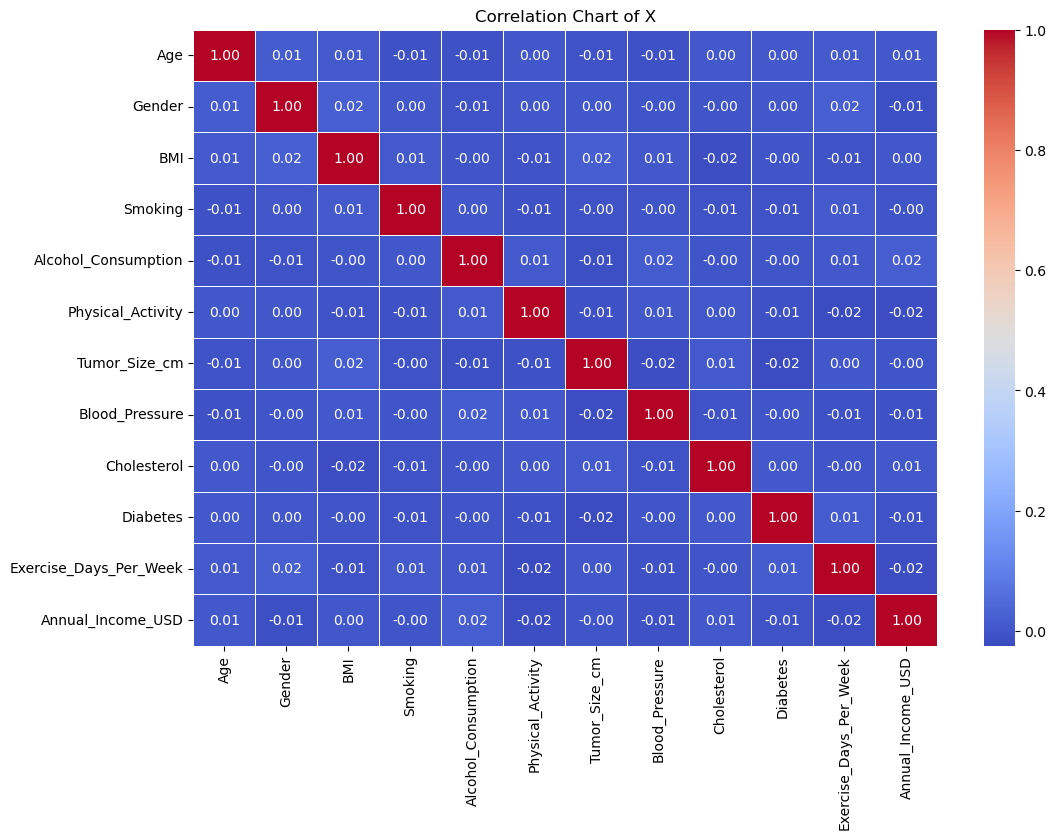

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
X_num = X.select_dtypes(include=["number"])

# Create correlation matrix
corral_matrix = X_num.corr()

# Create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corral_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Chart of X")
plt.show()